# Regressão Logística — Efeitos dos atributos via AME

Este notebook mensura o impacto de cada atributo no desfecho do sinistro (`gravidade`) usando os **Efeitos Marginais Médios (AME)** como medida de efeito.

O AME é definido como:
$$AME_k = E\left[\frac{\partial P(Y=1 | X)}{\partial x_k}\right]$$

Ele expressa a **variação média na probabilidade prevista** do evento associada a uma variação unitária em x_k — a mesma escala e interpretação do `SHAP_global_E[φ_k]` calculado nos demais modelos.

**Importante:** este notebook usa **exatamente as mesmas colunas** da base tratada utilizada por Random Forest, XGBoost e CatBoost, garantindo comparabilidade direta dos resultados.

In [66]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.6f}'.format)

In [52]:
url_train = "../../database/completo/final/df_train.csv"
url_test = "../../database/completo/final/df_test.csv"

# carrega dados
df_train = pd.read_csv(url_train, sep=",", encoding="UTF-8")
df_test = pd.read_csv(url_test, sep=",", encoding="UTF-8")

In [53]:
X_train = df_train.drop(columns=["grave", "ano"])
y_train = df_train["grave"]

X_test = df_test.drop(columns=["grave", "ano"])
y_test = df_test["grave"]

In [54]:
# ============================================================
# TREINAMENTO — Regressão Logística via statsmodels
# ============================================================
# statsmodels fornece get_margeff() para calcular os AMEs
# analiticamente.
#
# Desbalanceamento: peso inverso da frequência de cada classe,
# equivalente ao class_weight='balanced' dos demais modelos.

n_neg   = (y_train == 0).sum()
n_pos   = (y_train == 1).sum()
n_total = len(y_train)

pesos = y_train.map({
    0: n_total / (2 * n_neg),
    1: n_total / (2 * n_pos)
})

print(f"Desbalanceamento -- negativos: {n_neg:,} | positivos: {n_pos:,}")
print(f"Peso classe 0: {n_total / (2 * n_neg):.4f}")
print(f"Peso classe 1: {n_total / (2 * n_pos):.4f}")

X_train_const = sm.add_constant(X_train)

modelo = sm.Logit(y_train, X_train_const, freq_weights=pesos)
resultado_fit = modelo.fit(method="bfgs", maxiter=500, disp=False)

print("\nModelo treinado.")
print(f"Pseudo R2 de McFadden: {resultado_fit.prsquared:.4f}")
print(f"Log-likelihood: {resultado_fit.llf:.2f}")

Desbalanceamento -- negativos: 486,401 | positivos: 72,446
Peso classe 0: 0.5745
Peso classe 1: 3.8570

Modelo treinado.
Pseudo R2 de McFadden: 0.1086
Log-likelihood: -192136.58


In [55]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

X_test_const = sm.add_constant(X_test, has_constant='add')

y_prob = resultado_fit.predict(X_test_const)
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Metricas (Teste 2025) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))


=== Metricas (Teste 2025) ===
Accuracy : 0.8513
Precision: 0.2523
Recall   : 0.0274
F1-score : 0.0495
AUC      : 0.5863

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     62109
           1       0.25      0.03      0.05     10201

    accuracy                           0.85     72310
   macro avg       0.56      0.51      0.48     72310
weighted avg       0.77      0.85      0.80     72310



In [56]:
# ============================================================
# EFEITOS MARGINAIS MEDIOS (AME)
# ============================================================
# get_margeff() calcula para cada observacao i:
#   dP/dxk(i) = beta_k * P_hat(i) * (1 - P_hat(i))
# e retorna a media sobre todas as observacoes:
#   AME_k = E[dP/dxk]
#
# Isso e o analogo exato ao SHAP_global_E[phi_k]:
# variacao media em P(gravidade=1) atribuida a variavel k,
# na escala de probabilidade.
#
# at='overall' -> media sobre todas as observacoes de treino
# method='dydx' -> derivada parcial continua

margeff = resultado_fit.get_margeff(at='overall', method='dydx')

ame_df = pd.DataFrame({
    "AME":         margeff.margeff,
    "Erro_padrao": margeff.margeff_se,
    "p_valor":     margeff.pvalues,
    "IC_95_inf":   margeff.conf_int()[:, 0],
    "IC_95_sup":   margeff.conf_int()[:, 1],
}, index=X_train.columns)

# AME_abs: importancia absoluta -- analogo ao SHAP_importancia_E[|phi_k|]
ame_df["AME_abs"]       = ame_df["AME"].abs()
ame_df["significativo"] = ame_df["p_valor"] < 0.05
ame_df = ame_df.sort_values(by="AME_abs", ascending=False)

# ============================================================
# SAIDA NO MESMO FORMATO DO SHAP
# ============================================================
# Reproduz exatamente a estrutura das tabelas SHAP dos demais
# modelos para facilitar a comparacao direta.

resultado = ame_df[["AME", "AME_abs"]].copy()
resultado.columns = ["AME_global_E[dP/dxk]", "AME_importancia_E[|dP/dxk|]"]

print("\n=== Impacto dos atributos na probabilidade do desfecho (Regressao Logistica) ===")
print("AME_global_E[dP/dxk]        -> efeito medio com sinal, em unidades de probabilidade")
print("AME_importancia_E[|dP/dxk|] -> importancia absoluta, para ranqueamento")
print()
print(resultado.to_string())


=== Impacto dos atributos na probabilidade do desfecho (Regressao Logistica) ===
AME_global_E[dP/dxk]        -> efeito medio com sinal, em unidades de probabilidade
AME_importancia_E[|dP/dxk|] -> importancia absoluta, para ranqueamento

                    AME_global_E[dP/dxk]  AME_importancia_E[|dP/dxk|]
uf_br_km                        1.740513                     1.740513
vel_max                         0.036786                     0.036786
frequencia                      0.036177                     0.036177
condicao_ignorada               0.030599                     0.030599
pista_molhada                  -0.018537                     0.018537
declive                         0.014745                     0.014745
turno_cos                       0.014114                     0.014114
intersecao_de_vias             -0.010895                     0.010895
turno_sin                      -0.010615                     0.010615
dia_semana_sin                 -0.007552                     0

In [57]:
# ============================================================
# SIGNIFICANCIA ESTATISTICA
# ============================================================
# Vantagem do AME sobre o SHAP: acompanha erro padrao e
# p-valor, permitindo testar se o efeito e estatisticamente
# diferente de zero.

print("\n=== Significancia dos AMEs (alpha = 0.05) ===")
print(f"{'Variavel':35s}  {'AME':>9}  {'p-valor':>9}  {'Sig':>5}")
print("-" * 65)

for var, row in ame_df.iterrows():
    sig = "*" if row["p_valor"] < 0.05 else ""
    print(f"{var:35s}  {row['AME']:>+9.4f}  {row['p_valor']:>9.4f}  {sig:>5}")

print("\n* p-valor < 0.05")


=== Significancia dos AMEs (alpha = 0.05) ===
Variavel                                   AME    p-valor    Sig
-----------------------------------------------------------------
uf_br_km                               +1.7405     0.0000      *
vel_max                                +0.0368     0.0000      *
frequencia                             +0.0362     0.0000      *
condicao_ignorada                      +0.0306     0.0000      *
pista_molhada                          -0.0185     0.0001      *
declive                                +0.0147     0.0000      *
turno_cos                              +0.0141     0.0000      *
intersecao_de_vias                     -0.0109     0.0000      *
turno_sin                              -0.0106     0.0000      *
dia_semana_sin                         -0.0076     0.0000      *
distancia_radar_m                      +0.0071     0.0002      *
visibilidade_ruim                      -0.0063     0.1677       
uso_solo                               -0.

In [58]:
# ============================================================
# INTERPRETACAO DOS EFEITOS
# ============================================================
print("\n=== Interpretacao dos efeitos ===")
print("Variacao media em P(gravidade=1) atribuida a cada variavel.\n")

for var, row in ame_df.iterrows():
    ame     = row["AME"]
    ame_abs = row["AME_abs"]
    sig     = "*" if row["significativo"] else ""

    if ame_abs < 1e-8:
        print(f"{var:35s}: SEM EFEITO")
    elif ame > 0:
        print(f"{var:35s}: AUMENTA a probabilidade em +{ame:.4f} (em media) {sig}")
    else:
        print(f"{var:35s}: REDUZ  a probabilidade em {ame:.4f} (em media) {sig}")

print("\n* p-valor < 0.05")


=== Interpretacao dos efeitos ===
Variacao media em P(gravidade=1) atribuida a cada variavel.

uf_br_km                           : AUMENTA a probabilidade em +1.7405 (em media) *
vel_max                            : AUMENTA a probabilidade em +0.0368 (em media) *
frequencia                         : AUMENTA a probabilidade em +0.0362 (em media) *
condicao_ignorada                  : AUMENTA a probabilidade em +0.0306 (em media) *
pista_molhada                      : REDUZ  a probabilidade em -0.0185 (em media) *
declive                            : AUMENTA a probabilidade em +0.0147 (em media) *
turno_cos                          : AUMENTA a probabilidade em +0.0141 (em media) *
intersecao_de_vias                 : REDUZ  a probabilidade em -0.0109 (em media) *
turno_sin                          : REDUZ  a probabilidade em -0.0106 (em media) *
dia_semana_sin                     : REDUZ  a probabilidade em -0.0076 (em media) *
distancia_radar_m                  : AUMENTA a probabilida

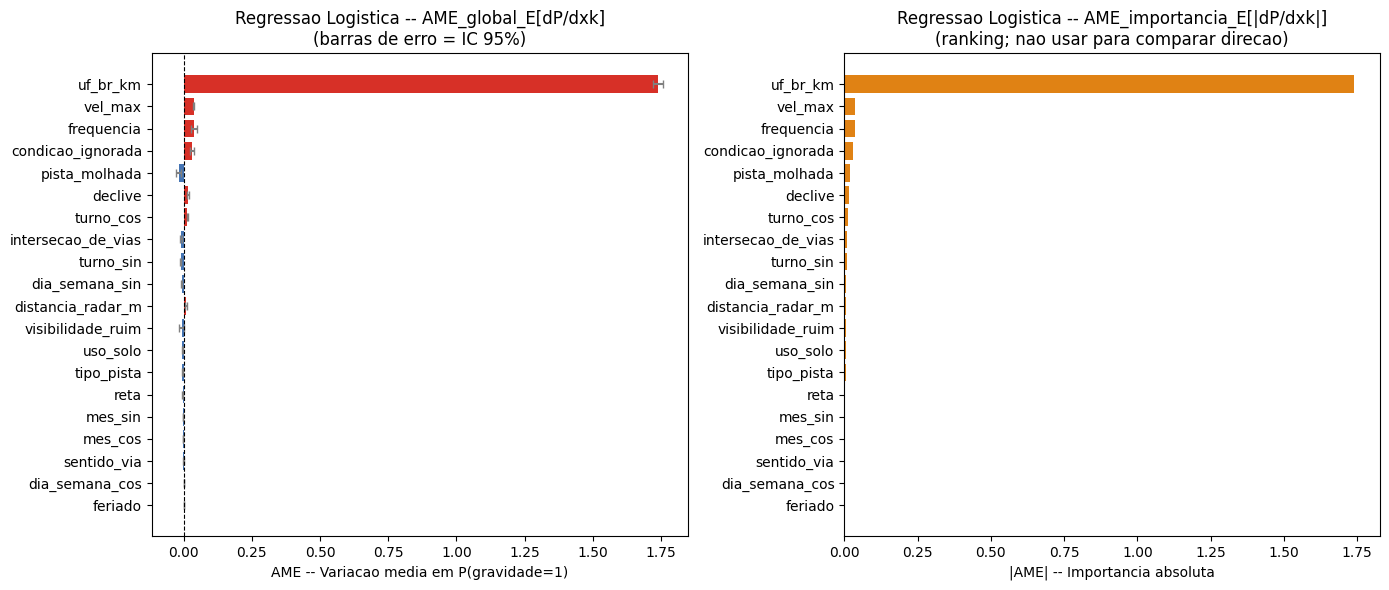

Grafico salvo em logit_ame_efeitos.png


In [59]:
# ============================================================
# VISUALIZACOES — mesmo layout dos graficos SHAP
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: AME com sinal e IC 95% (analogo ao SHAP_global)
cores = ['#d73027' if v > 0 else '#4575b4' for v in ame_df["AME"]]
yerr_low  = ame_df["AME"] - ame_df["IC_95_inf"]
yerr_high = ame_df["IC_95_sup"] - ame_df["AME"]

axes[0].barh(
    ame_df.index, ame_df["AME"],
    xerr=[yerr_low, yerr_high],
    color=cores, ecolor='gray', capsize=3
)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel("AME -- Variacao media em P(gravidade=1)")
axes[0].set_title("Regressao Logistica -- AME_global_E[dP/dxk]\n(barras de erro = IC 95%)")
axes[0].invert_yaxis()

# Grafico 2: importancia absoluta (analogo ao SHAP_importancia)
axes[1].barh(ame_df.index, ame_df["AME_abs"], color='#e08214')
axes[1].set_xlabel("|AME| -- Importancia absoluta")
axes[1].set_title("Regressao Logistica -- AME_importancia_E[|dP/dxk|]\n(ranking; nao usar para comparar direcao)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("logit_ame_efeitos.png", dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo em logit_ame_efeitos.png")

In [60]:
# ============================================================
# EXPORTACAO — mesmo formato das tabelas SHAP
# ============================================================
# Salva em CSV com as mesmas colunas usadas nas tabelas SHAP
# dos demais modelos para facilitar a comparacao entre modelos.

tabela_export = ame_df[["AME", "AME_abs", "p_valor", "IC_95_inf", "IC_95_sup"]].copy()
tabela_export.columns = [
    "SHAP_global_E[phi_k]",         # mesmo nome das tabelas SHAP
    "SHAP_importancia_E[|phi_k|]",  # mesmo nome das tabelas SHAP
    "p_valor",
    "IC_95_inf",
    "IC_95_sup"
]

print("\n=== Tabela no formato SHAP para comparacao entre modelos ===")
print("(colunas nomeadas igual aos demais modelos)\n")
print(tabela_export[["SHAP_global_E[phi_k]", "SHAP_importancia_E[|phi_k|]"]].to_string())

tabela_export.to_csv("logit_ames.csv")
print("\nSalvo em logit_ames.csv")


=== Tabela no formato SHAP para comparacao entre modelos ===
(colunas nomeadas igual aos demais modelos)

                    SHAP_global_E[phi_k]  SHAP_importancia_E[|phi_k|]
uf_br_km                        1.740513                     1.740513
vel_max                         0.036786                     0.036786
frequencia                      0.036177                     0.036177
condicao_ignorada               0.030599                     0.030599
pista_molhada                  -0.018537                     0.018537
declive                         0.014745                     0.014745
turno_cos                       0.014114                     0.014114
intersecao_de_vias             -0.010895                     0.010895
turno_sin                      -0.010615                     0.010615
dia_semana_sin                 -0.007552                     0.007552
distancia_radar_m               0.007128                     0.007128
visibilidade_ruim              -0.006307             

In [61]:
# ============================================================
# SUMARIO COMPLETO DO MODELO
# ============================================================
print(resultado_fit.summary2())

                           Results: Logit
Model:                Logit            Pseudo R-squared: 0.109      
Dependent Variable:   grave            AIC:              384315.1623
Date:                 2026-04-30 13:43 BIC:              384551.0685
No. Observations:     558847           Log-Likelihood:   -1.9214e+05
Df Model:             20               LL-Null:          -2.1554e+05
Df Residuals:         558826           LLR p-value:      0.0000     
Converged:            1.0000           Scale:            1.0000     
Method:               MLE                                           
--------------------------------------------------------------------
                    Coef.  Std.Err.     z     P>|z|   [0.025  0.975]
--------------------------------------------------------------------
const              -4.3701   0.0198 -220.2542 0.0000 -4.4090 -4.3313
sentido_via        -0.0195   0.0084   -2.3091 0.0209 -0.0360 -0.0029
pista_molhada      -0.1827   0.0464   -3.9360 0.0001 -0.2737 

In [62]:
import statsmodels.api as sm
import numpy as np

X_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_sm).fit()

def wald_cyclic(logit_model, X_columns, sin_name, cos_name):
    
    idx_sin = list(X_columns).index(sin_name)
    idx_cos = list(X_columns).index(cos_name)
    
    R = np.zeros((2, len(logit_model.params)))
    R[0, idx_sin] = 1
    R[1, idx_cos] = 1
    
    return logit_model.wald_test(R)

print(wald_cyclic(logit_model, X_sm.columns, "turno_sin", "turno_cos"))
print(wald_cyclic(logit_model, X_sm.columns, "dia_semana_sin", "dia_semana_cos"))
print(wald_cyclic(logit_model, X_sm.columns, "mes_sin", "mes_cos"))

Optimization terminated successfully.
         Current function value: 0.343809
         Iterations 7
<Wald test (chi2): statistic=[[795.58255483]], p-value=1.7435855850075086e-173, df_denom=2>
<Wald test (chi2): statistic=[[163.44759153]], p-value=3.2196336610590616e-36, df_denom=2>
<Wald test (chi2): statistic=[[29.90706442]], p-value=3.204523617500589e-07, df_denom=2>


In [63]:
def cyclic_ame_logit(model, X, sin_name, cos_name):
    
    p = model.predict()  # já está no X_sm
    mean_derivative = np.mean(p * (1 - p))
    
    idx_sin = list(X.columns).index(sin_name)
    idx_cos = list(X.columns).index(cos_name)
    
    beta_sin = model.params[idx_sin]
    beta_cos = model.params[idx_cos]
    
    amplitude = np.sqrt(beta_sin**2 + beta_cos**2)
    
    ame = amplitude * mean_derivative
    
    return ame

print(cyclic_ame_logit(logit_model, X_sm, "turno_sin", "turno_cos"))
print(cyclic_ame_logit(logit_model, X_sm, "dia_semana_sin", "dia_semana_cos"))
print(cyclic_ame_logit(logit_model, X_sm, "mes_sin", "mes_cos"))

0.017651717052657674
0.0077869595390315195
0.0033455143865466375


In [64]:
def plot_logit_cycle_labels(model, X, sin_name, cos_name, labels, offset=0):
    
    period = len(labels)
    
    idx_sin = list(X.columns).index(sin_name)
    idx_cos = list(X.columns).index(cos_name)
    
    beta_sin = model.params[idx_sin]
    beta_cos = model.params[idx_cos]
    
    p = model.predict(X)
    mean_derivative = np.mean(p * (1 - p))
    
    v = np.arange(0, period)
    theta = 2 * np.pi * (v - offset) / period
    
    effect = mean_derivative * (
        beta_sin * np.sin(theta) + beta_cos * np.cos(theta)
    )
    
    plt.figure(figsize=(8,4))
    plt.plot(labels, effect, marker='o')
    plt.axhline(0)
    plt.title(f"Ciclo (AME): {sin_name[:-4]}")
    plt.ylabel("Efeito na probabilidade")
    plt.grid()
    plt.show()

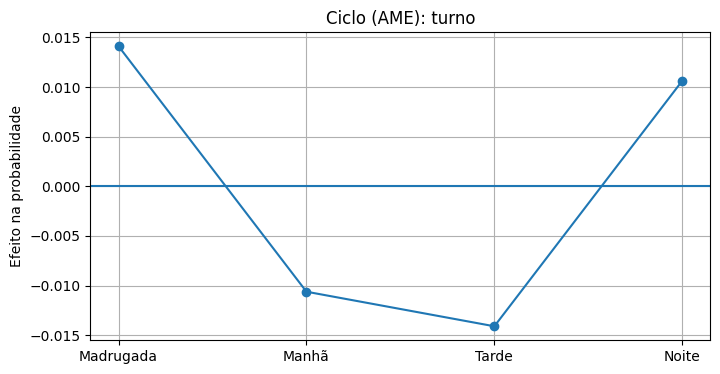

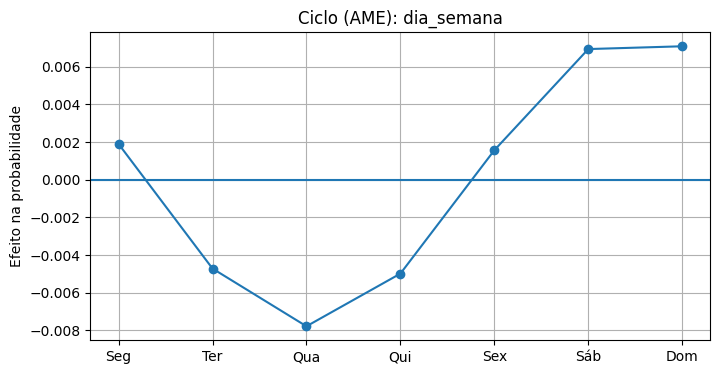

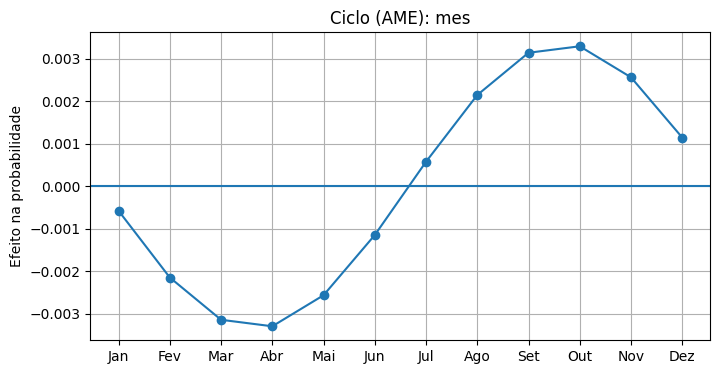

In [65]:
plot_logit_cycle_labels(
    logit_model, X_sm,
    "turno_sin", "turno_cos",
    ["Madrugada", "Manhã", "Tarde", "Noite"]
)

plot_logit_cycle_labels(
    logit_model, X_sm,
    "dia_semana_sin", "dia_semana_cos",
    ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
)

plot_logit_cycle_labels(
    logit_model, X_sm,
    "mes_sin", "mes_cos",
    ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
     "Jul", "Ago", "Set", "Out", "Nov", "Dez"],
    offset=1
)